In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
cm_celltypist = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/predictions_celltypist.csv')
cm_rf = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/Random_forest/prediction_results.csv')
cm_seurat = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/Label_transfer/predictions_seurat.csv')
cm_seurat["Predicted_label"] = cm_seurat.index

In [3]:
true_col = "Ground_truth"
pred_col = "Predicted_label"
y_true = cm_rf[true_col]
y_pred = cm_rf[pred_col]

In [4]:
gt_labels = np.unique(y_true)      # 10 GT classes
pred_labels = np.unique(y_pred)   # 19 predicted classes

cm_df = pd.crosstab(
    pd.Categorical(y_true, categories=gt_labels),
    pd.Categorical(y_pred, categories=pred_labels),
    dropna=False
)

# Normalize rows to get per-class recall
cm_row_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

In [5]:
np.unique(y_pred)

array(['CD8 T-cell', 'CLP', 'Dendritic Cell', 'ERP', 'Early-Erythroblast',
       'Eo/B/Mast', 'Erythroblast', 'Follicular B cell', 'GMP',
       'Granulocytic-UNK', 'HSC', 'Immature-Neutrophil', 'MDP', 'MEP',
       'MKP', 'MPP', 'Monocyte', 'NK cells', 'Naive T-cell', 'Neutrophil',
       'Plasma Cell', 'Pre-Dendritic', 'PreB', 'ProB', 'pre-PC'],
      dtype=object)

In [6]:
# Define lineage mapping and colors
lineage_map = {
    "HSC": "Stem",
    "MPP": "Stem",
    "CLP": "Lymphoid",
    "ProB": "Lymphoid",
    "PreB": "Lymphoid",
    "GMP": "Myeloid",
    "MDP": "Myeloid",
    "Eo/B/Mast": "Myeloid",
    "MEP": "Erythroid",
    "ERP": "Erythroid",
    "MKP": "Erythroid",
    "CD8 T-cell": "Lymphoid",
    "Follicular B cell": "Lymphoid",
    "Plasma Cell": "Lymphoid",
    "Immature-Neutrophil": "Lymphoid",
    "Dendritic Cell": "Myeloid",
    "Pre-Dendritic": "Myeloid",
    "Monocyte": "Myeloid",
    "Neutrophil": "Myeloid",
    "Eosinophil": "Myeloid",
    "Granulocytic-UNK": "Myeloid",
    "Early-Erythroblast": "Erythroid",
    "Erythroblast": "Erythroid",
    "Platelet": "Erythroid",
    "pre-PC": "Lymphoid",
    "Stromal": "Stromal", 
    "NK cells": "Lymphoid",
    "Naive T-cell": "Lymphoid"
}

lineage_colors = {
    "Stem": "black",
    "Lymphoid": "#b5838d",
    "Myeloid": "#6a994e",
    "Erythroid": "#d90429",
    "Stromal": "#ffb703"
}

In [7]:
# Functions for colors and sorting
def get_label_colors(labels, lineage_map, lineage_colors):
    colors = []
    for lab in labels:
        lineage = lineage_map.get(lab, None)
        if lineage is None:
            colors.append("black")  # fallback
        else:
            colors.append(lineage_colors.get(lineage, "black"))
    return colors

lineage_order = ["Stem", "Lymphoid", "Myeloid", "Erythroid", "Stromal"]

def sort_labels_by_lineage(labels, lineage_map, lineage_order):
    def sort_key(label):
        lineage = lineage_map.get(label, "Unknown")
        try:
            lineage_idx = lineage_order.index(lineage)
        except ValueError:
            lineage_idx = len(lineage_order)
        return (lineage_idx, label)
    return sorted(labels, key=sort_key)

def reorder_lineage_block(labels, gt_labels):
    """Within a lineage block, move labels shared with GT to the top."""
    shared = [l for l in labels if l in gt_labels]
    not_shared = [l for l in labels if l not in gt_labels]
    return shared + not_shared


# Reorder rows (GT) by lineage

sorted_rows = sort_labels_by_lineage(cm_row_norm.index, lineage_map, lineage_order)

# Reorder columns (Predicted labels) by lineage and GT sharing
gt_labels = set(cm_row_norm.index)
pred_labels = list(cm_row_norm.columns)

final_pred_order = []

for lineage in lineage_order:
    # Get predicted labels in this lineage
    block_labels = [l for l in pred_labels if lineage_map.get(l) == lineage]
    # Move ground truth-shared labels first within the block
    block_labels_sorted = reorder_lineage_block(block_labels, gt_labels)
    final_pred_order.extend(block_labels_sorted)

# Add any predicted labels not in lineage_map (fallback)
unknown_preds = [l for l in pred_labels if l not in final_pred_order]
final_pred_order.extend(unknown_preds)

# Reorder the confusion matrix
cm_final = cm_row_norm.loc[sorted_rows, final_pred_order]


# Assign colors to tick labels
row_colors = get_label_colors(cm_final.index, lineage_map, lineage_colors)
col_colors = get_label_colors(cm_final.columns, lineage_map, lineage_colors)

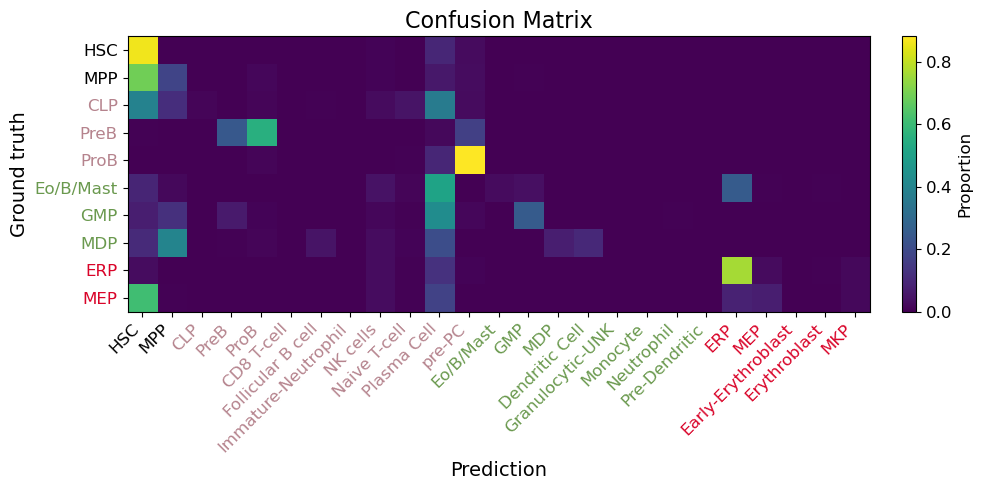

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))  # larger figure
im = ax.imshow(cm_final.values, aspect='auto', cmap='viridis')

# Axis ticks
ax.set_xticks(range(len(cm_final.columns)))
ax.set_yticks(range(len(cm_final.index)))

ax.set_xticklabels(cm_final.columns, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(cm_final.index, fontsize=12)

# Apply lineage colors
for tick, color in zip(ax.get_yticklabels(), row_colors):
    tick.set_color(color)
for tick, color in zip(ax.get_xticklabels(), col_colors):
    tick.set_color(color)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Proportion", fontsize=12)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel("Prediction", fontsize=14)
ax.set_ylabel("Ground truth", fontsize=14)
ax.set_title("Confusion Matrix", fontsize=16)

plt.tight_layout()

plt.savefig("/ibex/user/sotoorda/masterh1/LLM project/Additional_visualization/cm_seurat.pdf", dpi=300, format='pdf')
plt.show()